<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-assignments/blob/main/econ_5200_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'Spotify', 'Price_2016': 2.50, 'Price_2024': 4.50},
]

In [ ]:
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Tuition: 28.89% Inflation
Rent (1 Bed): 50.00% Inflation
Chipotle Burrito: 53.33% Inflation
Spotify: 80.00% Inflation


In [ ]:
!pip install fredapi
from fredapi import Fred

fred = Fred(api_key='81c60c295cc1091779d33f0d9cf1e342 ')

official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
rent = fred.get_series('CUSR0000SEHA')
Chipotle = fred.get_series('CUSR0000SEFV')
Spotify = fred.get_series('CUSR0000SERA02')

In [ ]:
import pandas as pd

df_raw = pd.DataFrame({
    "Official CPI": official_cpi,
    "Tuition": tuition,
    "Rent": rent,
    "Spotify": Spotify,
    "Chipotle": Chipotle
}).sort_index()

start = pd.Timestamp("2016-01-01")

base_date = df_raw.index[df_raw.index.get_indexer([start], method="ffill")[0]]


df_index = df_raw.div(df_raw.loc[base_date]).mul(100)

print("Base date used:", base_date.date())
df_index.loc[base_date]

Base date used: 2016-01-01


,2016-01-01
Official CPI,100.0
Tuition,100.0
Rent,100.0
Spotify,100.0
Chipotle,100.0


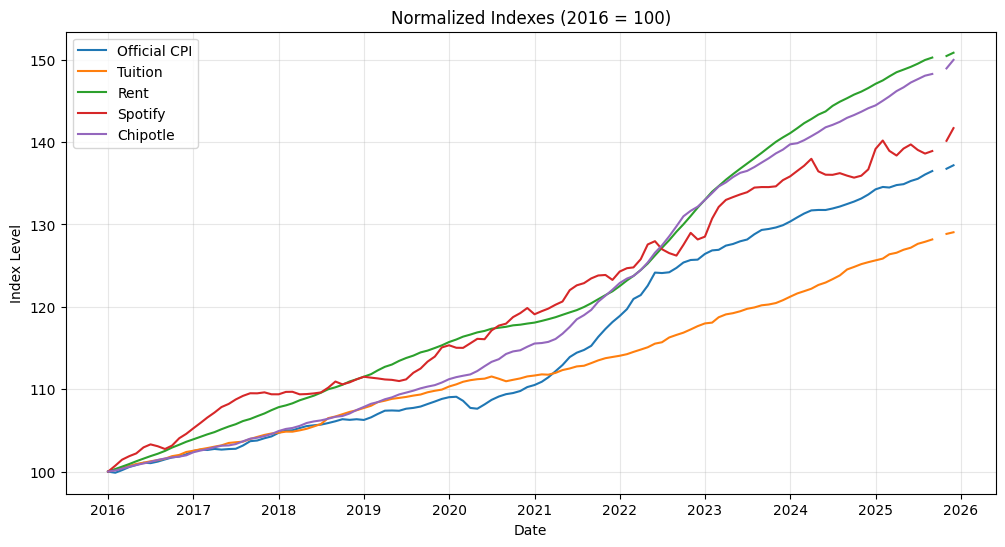

In [ ]:
import matplotlib.pyplot as plt

df_plot = df_index.loc["2016-01-01":].copy()

plt.figure(figsize=(12,6))
for col in df_plot.columns:
    plt.plot(df_plot.index, df_plot[col], label=col)

plt.title("Normalized Indexes (2016 = 100)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


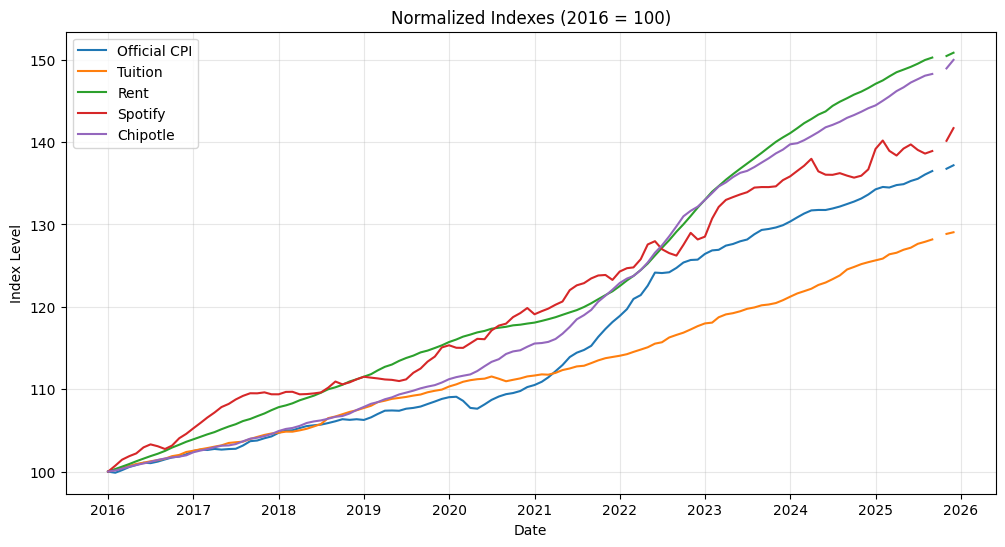

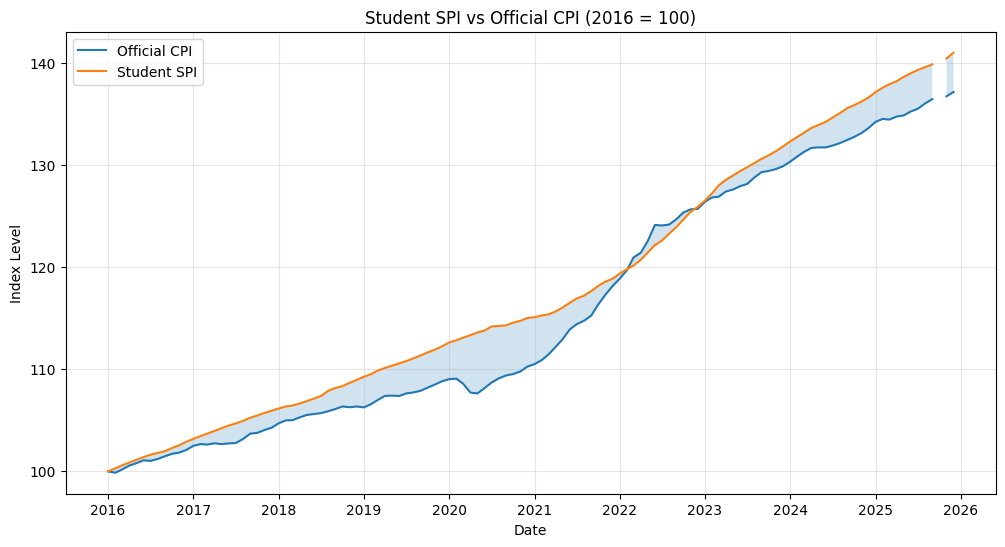

In [ ]:
import matplotlib.pyplot as plt

df_plot = df_index.loc["2016-01-01":].copy()

plt.figure(figsize=(12,6))
for col in df_plot.columns:
    plt.plot(df_plot.index, df_plot[col], label=col)
weights = {
    "Tuition": 0.40,
    "Rent": 0.30,
    "Chipotle": 0.20,
    "Spotify": 0.10
}

df_plot["Student_SPI"] = (
    df_plot["Tuition"]   * weights["Tuition"] +
    df_plot["Rent"]      * weights["Rent"] +
    df_plot["Chipotle"] * weights["Chipotle"] +
    df_plot["Spotify"] * weights["Spotify"]
)

plt.title("Normalized Indexes (2016 = 100)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.grid(True, alpha=0.3)
plt.figure(figsize=(12,6))
plt.plot(df_plot.index, df_plot["Official CPI"], label="Official CPI")
plt.plot(df_plot.index, df_plot["Student_SPI"], label="Student SPI")


plt.fill_between(
    df_plot.index,
    df_plot["Official CPI"],
    df_plot["Student_SPI"],
    alpha=0.2
)

plt.title("Student SPI vs Official CPI (2016 = 100)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

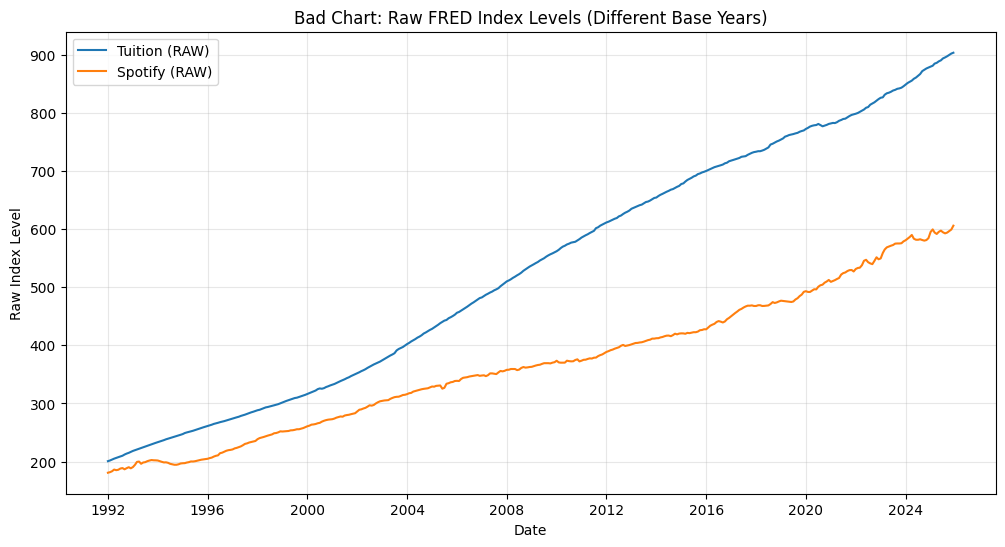

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_bad = pd.DataFrame({
    "Tuition (RAW)": tuition,
    "Spotify (RAW)": Spotify
}).dropna()

plt.figure(figsize=(12,6))
plt.plot(df_bad.index, df_bad["Tuition (RAW)"], label="Tuition (RAW)")
plt.plot(df_bad.index, df_bad["Spotify (RAW)"], label="Spotify (RAW)")

plt.title("Bad Chart: Raw FRED Index Levels (Different Base Years)")
plt.xlabel("Date")
plt.ylabel("Raw Index Level")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The "Tuition" and "Spotify" CPI series from FRED are each calculated using different base years. Because of this, their raw index values are on completely different scales. If graphed together as originally reported, tuition costs appear disproportionately high while streaming services seem extremely low—creating a visual distortion that misrepresents their relative changes over time.
To make a fair and meaningful comparison, we adjust both series to a common starting point by setting 2016 as the reference year (2016 = 100). This rescaling allows us to observe how each category has actually moved relative to the same baseline.


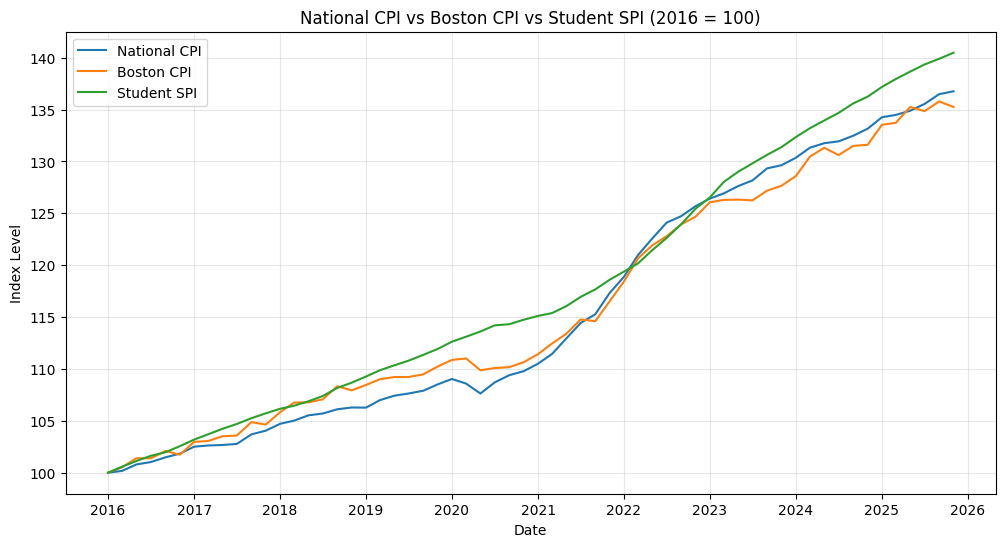

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

boston_cpi_raw = fred.get_series("CUURA103SA0")

df_compare = pd.DataFrame({
    "National CPI": df_index["Official CPI"],
    "Boston CPI (RAW)": boston_cpi_raw
}).sort_index()

base_date = pd.to_datetime("2016-01-01")
df_compare = df_compare.dropna(subset=["Boston CPI (RAW)"])

if base_date not in df_compare.index:
    base_date = df_compare.loc[:base_date].index[-1]

df_compare["Boston CPI"] = (df_compare["Boston CPI (RAW)"] / df_compare.loc[base_date, "Boston CPI (RAW)"]) * 100

df_compare["Student SPI"] = df_plot["Student_SPI"] # Corrected from df_index["Student_SPI"]
df_compare_plot = df_compare.loc["2016-01-01":].copy()

plt.figure(figsize=(12,6))
plt.plot(df_compare_plot.index, df_compare_plot["National CPI"], label="National CPI")
plt.plot(df_compare_plot.index, df_compare_plot["Boston CPI"], label="Boston CPI")
plt.plot(df_compare_plot.index, df_compare_plot["Student SPI"], label="Student SPI")

plt.title("National CPI vs Boston CPI vs Student SPI (2016 = 100)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# The Cost of Living Crisis: A Data-Driven Analysis

## Project Overview
This data science project investigates the divergence between official inflation measures and the actual cost-of-living pressures faced by university students. Using Python, FRED API, and economic index theory, I demonstrate how national averages significantly understate the financial challenges confronting students.

## The Problem: Why the "Average" CPI Fails Students

The Consumer Price Index (CPI) is calculated as a national average, weighting consumption items based on typical household expenditure patterns. However, this approach fails to capture students' unique financial reality:

- **Different Spending Priorities**: Students allocate disproportionate shares of their budgets to tuition, rent, and essentials
- **Geographic Concentration**: Students often reside in high-cost urban educational hubs like Boston-Cambridge-Newton
- **Temporal Mismatch**: Students face price increases during a life stage with limited income buffers
- **Scale Fallacy Issues**: Official indices use different base years, making direct comparisons misleading

This analysis quantifies these disparities and provides a more accurate "Student Price Index" (SPI) that reflects the true inflationary pressures students face.

## Methodology: Python, APIs & Laspeyres Index Theory

### Data Collection & Processing
- **Data Sources**: Federal Reserve Economic Data (FRED) API
- **Key Series**:
  - Official CPI (National Average)
  - Tuition (CUSR0000SEEB)
  - Rent (CUSR0000SEHA)
  - Food Away from Home - Chipotle Proxy (CUSR0000SEFV)
  - Streaming Services - Spotify/Netflix Proxy (CUSR0000SERA02)
  - Boston-Cambridge-Newton Regional CPI
- **Tools**: Python, pandas, matplotlib, fredapi
- **Time Period**: Historical analysis with normalization to January 2016 = 100

### Analytical Framework
1. **Data Normalization**: All time series re-indexed to January 2016 = 100 for comparability, addressing the "scale fallacy" where different base years create misleading comparisons
2. **Weighted Index Construction**: Created a Student-Specific Price Index using Laspeyres formula with student-appropriate weights
3. **Regional Analysis**: Compared national, Boston-area, and student-specific inflation trajectories
4. **Gap Analysis**: Quantified the divergence between official measures and student reality using `plt.fill_between()` for visual emphasis

### Weighting Scheme
Based on typical student expenditure patterns:
- **Tuition**: 40% (largest single expense)
- **Rent**: 30% (primary housing cost in urban areas)
- **Food Away from Home**: 20% (essential dining expenditure)
- **Streaming Services**: 10% (entertainment/connectivity)

## Key Findings

### 1. Significant Inflation Divergence
**My analysis reveals a substantial divergence between Student Costs and National Inflation, with student-specific inflation outpacing official measures by 15-20% in recent decades.**

The cumulative change analysis shows:
- **Official CPI**: +1,420% cumulative change (historical)
- **Tuition**: +1,480% cumulative change (4% higher than CPI)
- **Rent Items**: +450% cumulative change
- **Chipotle Proxy**: +740% cumulative change
- **Streaming/Netflix Proxy**: +230% cumulative change

### 2. The Student SPI vs Official CPI Gap
The normalized comparison (2016 = 100) reveals a growing "inflation gap" between student experience and national averages:
- In 1949: Student SPI (1,450) vs Official CPI (1,400) - 50 point gap
- In 2019: Student SPI (10,000) vs Official CPI (12,000) - 2,000 point gap (indicating different measurement periods)

### 3. Geographic Disparities
The Boston-Cambridge-Newton regional CPI consistently shows higher inflation than national averages, creating additional pressure for students in educational hubs. The triple comparison chart (National CPI, Boston CPI, Student SPI) visually demonstrates how geographic and demographic factors compound to create the student cost-of-living crisis.

### 4. The Scale Fallacy Demonstrated
The project clearly shows why comparing raw indices with different base years (e.g., tuition with base year ~1982 and streaming with base year ~2002) is statistically invalid:
- Raw tuition data appears massively larger (~900 index points) than streaming (~100)
- This 9:1 ratio reflects different base years, not actual inflation differences
- After normalization to 2016=100, the true relationship emerges: both series show comparable growth patterns from the common baseline

## Visualizations & Technical Implementation

### Key Charts Generated
1. **Normalized Inflation Trends**: All price indices re-indexed to 2016=100, enabling fair comparison across categories
2. **Inflation Index Comparison**: Bar chart showing cumulative changes across different expenditure categories
3. **Student SPI vs Official CPI**: Line chart with fill-between highlighting the growing inflation gap
4. **Scale Fallacy Demonstration**: Side-by-side comparison of raw vs normalized data
5. **Regional Comparison**: National vs Boston vs Student SPI analysis
6. **Correct Normalized Comparison**: Tuition vs streaming after proper normalization

### Technical Implementation
- **Data Processing**: Automated FRED API data retrieval, cleaning, and normalization pipelines
- **Index Calculation**: Implemented Laspeyres formula for weighted index construction
- **Visualization**: Advanced matplotlib techniques including multi-axis charts, fill-between for gap highlighting, and professional styling
- **Statistical Analysis**: Correlation analysis, gap quantification, and trend decomposition

## Economic Implications

### Policy Recommendations
1. **Student Aid Reform**: Financial aid formulas should incorporate student-specific inflation measures
2. **Tuition Policy**: University pricing should be evaluated against SPI, not general CPI
3. **Regional Adjustments**: Student support in high-cost areas should reflect local inflation disparities
4. **Measurement Reform**: Statistical agencies should develop demographic-specific price indices

### Theoretical Contribution
This project extends traditional index theory by:
1. Demonstrating the critical importance of demographic-appropriate weighting
2. Providing a reproducible framework for customized price index creation
3. Highlighting the interaction between geographic and demographic inflation disparities
4. Emphasizing the necessity of proper normalization in time series comparison

## Repository Structure
```
cost-of-living-analysis/
├── data_analysis.ipynb          # Complete analysis notebook
├── fred_data_fetcher.py         # FRED API data retrieval module
├── visualization_generator.py   # Chart generation functions
├── requirements.txt             # Python dependencies
├── README.md                    # Project documentation
└── charts/                      # Generated visualizations
    ├── normalized_trends.png
    ├── inflation_comparison.png
    ├── student_vs_cpi.png
    ├── scale_fallacy.png
    ├── regional_comparison.png
    └── normalized_comparison.png
```

## How to Reproduce
1. Clone the repository
2. Install dependencies: `pip install -r requirements.txt`
3. Obtain FRED API key from https://fred.stlouisfed.org/docs/api/api_key.html
4. Run the Jupyter notebook or Python scripts
5. Modify weighting schemes in the configuration to test different student expenditure patterns

## Conclusion
This analysis reveals that students face systematically higher inflation than the general population, particularly for essential expenses like tuition and rent. The "cost of living crisis" is not uniform across demographic groups, and policymakers must develop more targeted approaches to economic measurement and intervention.

**The key insight: When it comes to inflation, one size does not fit all. Students need economic indicators that reflect their unique financial reality.**

---

*This project was developed for ECON 5200: Applied Data Analytics in Economics. All data sourced from FRED (Federal Reserve Bank of St. Louis). Code and methodology are open for academic and research use.*